# PINN on Simulink Data - Scenario 1

## What this notebook does
This notebook trains a PINN directly on Simulink trajectory data for Scenario 1 and evaluates how well the learned trajectory matches the Simulink reference. It is designed to be a hybrid setup with three supervision signals:
- Kinematic residual consistency
- Supervised trajectory fitting
- Initial-condition anchoring

The goal is practical trajectory matching under fault dynamics while keeping a physically meaningful constraint through the kinematic relation.

## Data source and split (Simulink-first workflow)
Inputs are loaded from two MAT files:
- scenario_1_simulink_outputs.mat: full trajectory arrays
- scenario_1_train_test.mat: train/test index split and scenario metadata

Loaded variables include:
- T_ref: time vector
- delta_ref_raw: rotor angles from Simulink (wrapped form)
- omega_ref: rotor speed trajectories
- idx_train, idx_test: training/validation partition
- fault timing metadata: t_fault_start, t_fault_clear

Important preprocessing:
- Angles are unwrapped into delta_ref for training stability.
- Original wrapped delta_ref_raw is preserved for final wrapped-angle error reporting.
- Per-channel normalization scales are computed on training indices only (delta_scale, omega_scale).

## Model outputs and parameterization
The network predicts 6 outputs at each time t:
- 3 angle channels (delta)
- 3 speed channels (omega)

The forward map enforces initial-state form by construction:
- delta(t) = delta0 + t * delta_net(t)
- omega(t) = omega0 + t * omega_net(t)

This improves early-time behavior and keeps predictions anchored near t = 0.

## Physics used in this notebook
This notebook uses kinematic physics only (not swing-network dynamics):
- Kinematic residual: d(delta)/dt - omega

No electrical-power residual or second-order swing residual is included in the optimization objective here.

## Hybrid training objective
Total loss is:
- PDE term: weighted kinematic residual MSE on collocation points
- IC term: MSE to initial angle/speed at t = 0
- Data term: normalized supervised MSE on delta and omega

With scalar weighting in code:
- total = pde_w * pde_loss + IC_WEIGHT * ic_loss + DATA_WEIGHT * data_loss

And data_loss uses an omega emphasis:
- data_loss = mean((delta error / delta_scale)^2) + OMEGA_DATA_BOOST * mean((omega error / omega_scale)^2)

## Curriculum schedule
Physics weight pde_w is scheduled in three phases:
- Pretrain phase: pde_w = 0 (data + IC only)
- Warmup phase: pde_w increases smoothly (quadratic ramp)
- Final phase: pde_w reaches PDE_WEIGHT_TARGET

This prevents early over-constraining before the network has learned a reasonable trajectory fit.

## Fault-aware sampling
Training points are sampled non-uniformly from idx_train:
- Base weight = 1
- Extra weight near transient window [fault_lo, TRANSIENT_END]
- Strong extra weight near fault window [fault_start - margin, fault_clear + margin]

This increases effective learning focus on hard transient dynamics and fault clearing behavior.

## Multi-GPU behavior
If multiple CUDA devices are available, the model is wrapped with DataParallel to match RK4 notebook multi-GPU behavior. Initial condition tensors are moved to the local replica device inside forward to avoid device mismatch.

## Validation, early stopping, and checkpoint restore
Validation is computed on idx_test only using the same normalized supervised metric.

Training loop behavior:
- Evaluate validation every VAL_EVERY iterations
- Track best validation loss with MIN_VAL_IMPROVEMENT threshold
- Stop when no improvement for EARLY_STOP_PATIENCE checks
- Restore best_state before final evaluation/export

This ensures final exported curves come from the best validation model, not simply the last iteration.

## Evaluation and saved artifact
After restoring best validation checkpoint, notebook computes:
- Wrapped-angle absolute error in degrees per generator
- max_error_deg and mean_error_deg
- Comparison plots (error, angle trajectories, speed trajectories)

Saved NPZ contains:
- T_ref, delta_ref (raw wrapped), omega_ref
- delta_pinn (wrapped), omega_pinn
- max_error_deg, mean_error_deg

## Differences from RK4-PINN notebooks (explicit)
Given you already know the RK4 PINN notebooks, the key differences here are:
- Reference source: Simulink trajectory files instead of internally generated RK4 reference.
- Split strategy: explicit train/test index split from MAT metadata.
- Physics objective: kinematic residual only in this version (no swing-network residual term).
- Sampling: fault/transient-weighted stochastic sampling tied to Simulink event timing.
- Validation policy: mandatory idx_test validation + early stopping + best-checkpoint restore before export.
- Error reporting: wrapped-angle error against Simulink raw angle channels.
- Data path assumptions: Kaggle dataset paths are used by default in this file.

## How to read this notebook end-to-end
1. Config cell defines training budget, weights, curriculum, and validation policy.
2. Data-loading cell maps Simulink MAT content and event metadata into tensors.
3. Sampling cell constructs weighted training distribution and validation tensors.
4. Physics cell defines kinematic residual operator.
5. Model/loss cell defines network, loss terms, and validation metric.
6. Train cell performs curriculum training with early stopping/checkpointing.
7. Evaluate cell restores best model outputs, computes metrics, plots, and saves NPZ.

If you keep these sections in mind, every code cell maps directly to one block of the above training pipeline.

In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.autograd as autograd
from scipy.io import loadmat

torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Configuration
SCENARIO_ID = 1

# Multi-GPU setup (Kaggle 2xT4 compatible)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
print(f"Available GPUs: {torch.cuda.device_count()}")
if torch.cuda.device_count() > 0:
    print(f"GPU devices: {[torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())]}")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# 3x intensified training budget (iterations + samples)
NUM_ITERS = 90000
LEARNING_RATE = 3e-4
WIDTH = 512
DEPTH = 8

# Hybrid curriculum: first fit data, then slowly turn on kinematic residual.
PDE_WEIGHT_TARGET = 0.03
PRETRAIN_ITERS = 16000
PDE_WARMUP_ITERS = 24000

IC_WEIGHT = 10.0
DATA_WEIGHT = 2.0
OMEGA_DATA_BOOST = 20.0

BATCH_COLLOC = 6144
BATCH_DATA = 12288
FAULT_MARGIN = 0.05
FAULT_WEIGHT = 300.0
TRANSIENT_END = 5.0
TRANSIENT_WEIGHT = 8.0
PRINT_EVERY = 200


VAL_EVERY = 400
EARLY_STOP_PATIENCE = 70
MIN_VAL_IMPROVEMENT = 1e-4


# HEAVY TRAINING: 5x everything for maximum accuracy
NUM_ITERS = 250000
LEARNING_RATE = 3e-4
WIDTH = 512
DEPTH = 8

# Prioritize direct Simulink matching: disable PDE term for fastest convergence.
PDE_WEIGHT_TARGET = 0.0
PRETRAIN_ITERS = 0
PDE_WARMUP_ITERS = 0

IC_WEIGHT = 20.0
DATA_WEIGHT = 5.0
OMEGA_DATA_BOOST = 100.0

BATCH_COLLOC = 15000
BATCH_DATA = 30000
BATCH_FAULT = 8000
FAULT_FIT_WEIGHT = 12.0
FAULT_MARGIN = 0.05
FAULT_WEIGHT = 500.0
TRANSIENT_END = 5.0
TRANSIENT_WEIGHT = 15.0
PRINT_EVERY = 200

VAL_EVERY = 300
EARLY_STOP_PATIENCE = 100
MIN_VAL_IMPROVEMENT = 5e-5

print(f'Network: {WIDTH}x{DEPTH}, Iters: {NUM_ITERS}')
print(f'Curriculum: pretrain={PRETRAIN_ITERS}, warmup={PDE_WARMUP_ITERS}')
print(f'Validation: every={VAL_EVERY}, patience={EARLY_STOP_PATIENCE}')

Using device: cuda
Available GPUs: 2
GPU devices: ['Tesla T4', 'Tesla T4']
Network: 512x8, Iters: 250000
Curriculum: pretrain=0, warmup=0
Validation: every=300, patience=100


In [3]:
# Load Simulink outputs
candidate_mat_full = [
    '/kaggle/input/datasets/tanishksarode/simulink/scenario_1_simulink_outputs.mat',
    '/kaggle/input/datasets/sanskrutihansdah/simulink-reference-outputs/scenario_1_simulink_outputs.mat',
    os.path.join('..', 'simulink_reference_outputs', f'scenario_{SCENARIO_ID}_simulink_outputs.mat'),
]
candidate_mat_split = [
    '/kaggle/input/datasets/tanishksarode/simulink/scenario_1_train_test.mat',
    '/kaggle/input/datasets/sanskrutihansdah/simulink-reference-outputs/scenario_1_train_test.mat',
    os.path.join('..', 'simulink_reference_outputs', f'scenario_{SCENARIO_ID}_train_test.mat'),
]

def _first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return paths[0]

mat_full = _first_existing(candidate_mat_full)
mat_split = _first_existing(candidate_mat_split)

if not os.path.exists(mat_full):
    raise FileNotFoundError(f'Missing scenario MAT file. Checked: {candidate_mat_full}')
if not os.path.exists(mat_split):
    raise FileNotFoundError(f'Missing split MAT file. Checked: {candidate_mat_split}')

print('Using MAT full:', mat_full)
print('Using MAT split:', mat_split)

full = loadmat(mat_full)
split = loadmat(mat_split)

def _get_scalar(mat_dict, keys, default):
    for key in keys:
        if key in mat_dict:
            arr = np.asarray(mat_dict[key]).reshape(-1)
            if arr.size > 0:
                return float(arr[0])
    return float(default)

T_ref = full['T_ref'].reshape(-1).astype(np.float32)
delta_ref_raw = full['delta_ref'].astype(np.float32)
# Train on unwrapped angles to avoid artificial jump errors from angle wrapping.
delta_ref = np.unwrap(delta_ref_raw, axis=0).astype(np.float32)
omega_ref = full['omega_ref'].astype(np.float32)

idx_train = split['idx_train'].reshape(-1).astype(np.int64) - 1
idx_test = split['idx_test'].reshape(-1).astype(np.int64) - 1

omega_mode = str(split.get('omega_mode_used', np.array(['unknown'])).reshape(-1)[0])
kin_mae_auto = float(split.get('kin_mae_auto', np.array([[np.nan]])).reshape(-1)[0])

t_fault_start = _get_scalar(split, ['t_fault_start', 'ft'], 0.0)
t_fault_clear = _get_scalar(split, ['t_fault_clear', 'ct'], t_fault_start)

delta0 = delta_ref[0]
omega0 = omega_ref[0]
t_end = float(T_ref[-1])

delta_scale = np.std(delta_ref[idx_train], axis=0).astype(np.float32) + 1e-6
omega_scale = np.std(omega_ref[idx_train], axis=0).astype(np.float32) + 1e-6

print(f'T_ref shape: {T_ref.shape}')
print(f'delta_ref(raw) shape: {delta_ref_raw.shape}')
print(f'omega_ref shape: {omega_ref.shape}')
print(f'train points: {len(idx_train)}, test points: {len(idx_test)}')
print(f'fault window: [{t_fault_start:.4f}, {t_fault_clear:.4f}] s (base)')
print(f'fault margin: +/-{FAULT_MARGIN:.4f} s')
print(f'omega_mode_used: {omega_mode}')
print(f'generator-side kin_mae_auto: {kin_mae_auto:.6f} rad/s')
print(f'delta_scale: {delta_scale}')
print(f'omega_scale: {omega_scale}')

Using MAT full: /kaggle/input/datasets/tanishksarode/simulink/scenario_1_simulink_outputs.mat
Using MAT split: /kaggle/input/datasets/tanishksarode/simulink/scenario_1_train_test.mat
T_ref shape: (40001,)
delta_ref(raw) shape: (40001, 3)
omega_ref shape: (40001, 3)
train points: 32001, test points: 8000
fault window: [1.0000, 1.0833] s (base)
fault margin: +/-0.0500 s
omega_mode_used: rad_s_deviation
generator-side kin_mae_auto: 0.097842 rad/s
delta_scale: [0.02824941 0.05732872 0.04044216]
omega_scale: [0.01137872 0.01141225 0.01129637]


In [4]:
# Build training/validation tensors and weighted train sampling distribution
train_t_np = T_ref[idx_train]
fault_lo = max(float(T_ref[0]), t_fault_start - FAULT_MARGIN)
fault_hi = min(t_end, t_fault_clear + FAULT_MARGIN)

fault_mask_train = (train_t_np >= fault_lo) & (train_t_np <= fault_hi)
transient_mask_train = (train_t_np >= fault_lo) & (train_t_np <= TRANSIENT_END)

sample_w_np = np.ones(len(idx_train), dtype=np.float64)
sample_w_np[transient_mask_train] += TRANSIENT_WEIGHT
sample_w_np[fault_mask_train] += FAULT_WEIGHT
sample_prob_np = sample_w_np / np.sum(sample_w_np)

t_train_all = torch.tensor(train_t_np, dtype=torch.float32, device=DEVICE).view(-1, 1)
delta_train_all = torch.tensor(delta_ref[idx_train], dtype=torch.float32, device=DEVICE)
omega_train_all = torch.tensor(omega_ref[idx_train], dtype=torch.float32, device=DEVICE)

t_val_all = torch.tensor(T_ref[idx_test], dtype=torch.float32, device=DEVICE).view(-1, 1)
delta_val_all = torch.tensor(delta_ref[idx_test], dtype=torch.float32, device=DEVICE)
omega_val_all = torch.tensor(omega_ref[idx_test], dtype=torch.float32, device=DEVICE)

sample_prob_t = torch.tensor(sample_prob_np, dtype=torch.float32, device=DEVICE)
delta_scale_t = torch.tensor(delta_scale, dtype=torch.float32, device=DEVICE).view(1, 3)
omega_scale_t = torch.tensor(omega_scale, dtype=torch.float32, device=DEVICE).view(1, 3)

t_ic = torch.zeros((256, 1), dtype=torch.float32, device=DEVICE)
delta0_t = torch.tensor(delta0, dtype=torch.float32, device=DEVICE)
omega0_t = torch.tensor(omega0, dtype=torch.float32, device=DEVICE)

t_eval = torch.tensor(T_ref, dtype=torch.float32, device=DEVICE).view(-1, 1)

print(f'fault points in train set: {int(fault_mask_train.sum())}/{len(idx_train)}')
print(f'transient points in train set: {int(transient_mask_train.sum())}/{len(idx_train)}')
print(f'fault sampling mass: {float(sample_prob_np[fault_mask_train].sum()):.4f}')
print(f'transient sampling mass: {float(sample_prob_np[transient_mask_train].sum()):.4f}')
print(f'validation points: {t_val_all.shape[0]}')

fault points in train set: 295/32001
transient points in train set: 6522/32001
fault sampling mass: 0.5489
transient sampling mass: 0.9081
validation points: 8000


In [5]:
# Hybrid physics setup: kinematic residual only
def kinematic_residual(delta_pred, omega_pred, t_in):
    ddt = torch.zeros_like(delta_pred)
    for i in range(3):
        ddt[:, i:i+1] = autograd.grad(
            delta_pred[:, i:i+1], t_in, torch.ones_like(delta_pred[:, i:i+1]),
            retain_graph=True, create_graph=True
        )[0]
    return ddt - omega_pred

print('Hybrid physics initialized (kinematic residual only).')

Hybrid physics initialized (kinematic residual only).


In [6]:
# # Physics parameters and network model (Scenario 1 baseline)
# f = 60.0
# w_s = 2.0 * np.pi * f

# D = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32, device=DEVICE)
# H = torch.tensor([23.64, 6.40, 3.01], dtype=torch.float32, device=DEVICE)
# Pm = torch.tensor([0.716, 1.63, 0.85], dtype=torch.float32, device=DEVICE)
# E = torch.tensor([1.0566, 1.0502, 1.0170], dtype=torch.float32, device=DEVICE)
# M = 2.0 * H / w_s

# def Y_from_entries(entries):
#     Y = torch.zeros((3, 3), dtype=torch.complex64, device=DEVICE)
#     for i, j, gr, gi in entries:
#         Y[i, j] = torch.complex(torch.tensor(gr, dtype=torch.float32, device=DEVICE), torch.tensor(gi, dtype=torch.float32, device=DEVICE))
#     return Y

# Y_fault = Y_from_entries([
#     (0, 0, 0.657, -3.816), (0, 1, 0.000, 0.000), (0, 2, 0.070, 0.631),
#     (1, 0, 0.000, 0.000), (1, 1, 0.000, -5.486), (1, 2, 0.000, 0.000),
#     (2, 0, 0.070, 0.631), (2, 1, 0.000, 0.000), (2, 2, 0.174, -2.796),
# ])

# Y_clear = Y_from_entries([
#     (0, 0, 1.181, -2.229), (0, 1, 0.138, 0.726), (0, 2, 0.191, 1.079),
#     (1, 0, 0.138, 0.726), (1, 1, 0.389, -1.953), (1, 2, 0.199, 1.229),
#     (2, 0, 0.191, 1.079), (2, 1, 0.199, 1.229), (2, 2, 0.273, -2.342),
# ])

# def piecewise_Y(t):
#     Yb = torch.zeros((t.shape[0], 3, 3), dtype=torch.complex64, device=t.device)
#     mask_fault = (t < t_fault_clear)
#     Yb[mask_fault] = Y_fault.to(t.device)
#     Yb[~mask_fault] = Y_clear.to(t.device)
#     return Yb

# def electrical_power(delta, Evec, Ybatch):
#     Ecol = Evec.to(delta.device).view(1, 3)
#     dmat = delta.unsqueeze(2) - delta.unsqueeze(1)
#     G = Ybatch.real
#     B = Ybatch.imag
#     term = G * torch.cos(dmat) + B * torch.sin(dmat)
#     EE = Ecol.unsqueeze(2) * Ecol.unsqueeze(1)
#     P = EE * term
#     return torch.sum(P, dim=2)

# print('Physics model initialized (swing + network equations).')

In [7]:
class PINN(nn.Module):
    def __init__(self, width=256, depth=6):
        super().__init__()
        layers = []
        in_dim = 1
        for i in range(depth):
            layers.append(nn.Linear(in_dim, width))
            if i < depth - 1:
                layers.append(nn.Tanh())
            in_dim = width
        self.body = nn.Sequential(*layers)
        self.out = nn.Linear(width, 6)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        x = t / t_end
        z = self.body(x)
        y = self.out(z)

        delta = y[:, :3]
        omega = y[:, 3:]

        # Keep IC tensors on each local replica under DataParallel.
        delta0_local = delta0_t.unsqueeze(0).to(t.device)
        omega0_local = omega0_t.unsqueeze(0).to(t.device)
        delta = delta0_local + t * delta
        omega = omega0_local + t * omega
        return delta, omega

def pde_weight_schedule(it):
    if it < PRETRAIN_ITERS:
        return 0.0
    if it < PRETRAIN_ITERS + PDE_WARMUP_ITERS:
        frac = (it - PRETRAIN_ITERS) / max(1, PDE_WARMUP_ITERS)
        return PDE_WEIGHT_TARGET * (frac ** 2)
    return PDE_WEIGHT_TARGET

torch.manual_seed(42)
net = PINN(width=WIDTH, depth=DEPTH).to(DEVICE)

# Use both GPUs when available (matches RK4 notebook behavior).
if torch.cuda.device_count() > 1:
    print(f"Using DataParallel with {torch.cuda.device_count()} GPUs")
    net = nn.DataParallel(net)

opt = torch.optim.Adam(net.parameters(), lr=LEARNING_RATE)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_ITERS, eta_min=5e-6)

def data_loss_term(d_pred, w_pred, d_target, w_target):
    d_err = (d_pred - d_target) / delta_scale_t
    w_err = (w_pred - w_target) / omega_scale_t
    return torch.mean(d_err ** 2) + OMEGA_DATA_BOOST * torch.mean(w_err ** 2)

def pinn_loss(pde_w):
    if pde_w > 0.0:
        colloc_idx = torch.multinomial(sample_prob_t, num_samples=BATCH_COLLOC, replacement=True)
        tc = t_train_all[colloc_idx].clone().detach().requires_grad_(True)
        d_c, w_c = net(tc)
        kin_res = kinematic_residual(d_c, w_c, tc)
        pde_loss = torch.mean(kin_res ** 2)
    else:
        pde_loss = torch.zeros((), dtype=torch.float32, device=DEVICE)

    d0, w0 = net(t_ic)
    ic_loss = torch.mean((d0 - delta0_t) ** 2) + torch.mean((w0 - omega0_t) ** 2)

    data_idx = torch.multinomial(sample_prob_t, num_samples=BATCH_DATA, replacement=True)
    t_data = t_train_all[data_idx]
    d_target = delta_train_all[data_idx]
    w_target = omega_train_all[data_idx]

    d_pred, w_pred = net(t_data)
    data_loss = data_loss_term(d_pred, w_pred, d_target, w_target)

    total = (
        pde_w * pde_loss
        + IC_WEIGHT * ic_loss
        + DATA_WEIGHT * data_loss
    )
    return total, pde_loss.detach().item(), ic_loss.detach().item(), data_loss.detach().item()

def evaluate_validation(batch_size=4096):
    net.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        n = t_val_all.shape[0]
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            t_b = t_val_all[start:end]
            d_t = delta_val_all[start:end]
            w_t = omega_val_all[start:end]
            d_p, w_p = net(t_b)
            l = data_loss_term(d_p, w_p, d_t, w_t)
            bs = end - start
            total += float(l.detach().item()) * bs
            count += bs
    net.train()
    return total / max(1, count)

Using DataParallel with 2 GPUs


In [8]:
# Train
history = []
best_train = float('inf')
best_val = float('inf')
best_iter = 0
best_state = copy.deepcopy(net.state_dict())
wait = 0
stopped_early = False

for it in range(NUM_ITERS):
    pde_w = pde_weight_schedule(it)

    opt.zero_grad(set_to_none=True)
    loss, l_pde, l_ic, l_data = pinn_loss(pde_w)

    if not torch.isfinite(loss):
        print(f'Non-finite loss at iter {it+1}. Stopping training.')
        stopped_early = True
        break

    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(net.parameters(), 0.5)
    if not torch.isfinite(grad_norm):
        print(f'Non-finite gradient norm at iter {it+1}. Stopping training.')
        stopped_early = True
        break

    opt.step()
    sched.step()

    lv = float(loss.detach().item())
    if lv < best_train:
        best_train = lv

    if (it + 1) % VAL_EVERY == 0:
        val_loss = evaluate_validation()
        improved = val_loss < (best_val - MIN_VAL_IMPROVEMENT)
        if improved:
            best_val = val_loss
            best_iter = it + 1
            best_state = copy.deepcopy(net.state_dict())
            wait = 0
        else:
            wait += 1

        lr_now = float(opt.param_groups[0]['lr'])
        history.append((it + 1, lv, l_pde, l_ic, l_data, val_loss, lr_now, pde_w))
        print(
            f'iter {it+1:5d}: total={lv:.4e} pde={l_pde:.4e} '
            f'ic={l_ic:.4e} data={l_data:.4e} val={val_loss:.4e} '
            f'pde_w={pde_w:.4f} lr={lr_now:.2e} wait={wait:02d}'
        )

        if wait >= EARLY_STOP_PATIENCE:
            print(f'Early stopping triggered at iter {it+1}.')
            stopped_early = True
            break
    elif (it + 1) % PRINT_EVERY == 0:
        lr_now = float(opt.param_groups[0]['lr'])
        print(
            f'iter {it+1:5d}: total={lv:.4e} pde={l_pde:.4e} '
            f'ic={l_ic:.4e} data={l_data:.4e} pde_w={pde_w:.4f} lr={lr_now:.2e}'
        )

net.load_state_dict(best_state)
status = 'stopped early' if stopped_early else 'completed'
print(f'Training {status}. best_train={best_train:.4e}, best_val={best_val:.4e} at iter {best_iter}')

iter   200: total=1.7792e+02 pde=0.0000e+00 ic=0.0000e+00 data=3.5584e+01 pde_w=0.0000 lr=3.00e-04
iter   300: total=1.3706e+03 pde=0.0000e+00 ic=0.0000e+00 data=2.7412e+02 val=1.4136e+03 pde_w=0.0000 lr=3.00e-04 wait=00
iter   400: total=1.7337e+02 pde=0.0000e+00 ic=0.0000e+00 data=3.4675e+01 pde_w=0.0000 lr=3.00e-04
iter   600: total=1.5511e+02 pde=0.0000e+00 ic=0.0000e+00 data=3.1023e+01 val=1.5196e+02 pde_w=0.0000 lr=3.00e-04 wait=00
iter   800: total=1.4637e+02 pde=0.0000e+00 ic=0.0000e+00 data=2.9275e+01 pde_w=0.0000 lr=3.00e-04
iter   900: total=1.3593e+02 pde=0.0000e+00 ic=0.0000e+00 data=2.7185e+01 val=1.4452e+01 pde_w=0.0000 lr=3.00e-04 wait=00
iter  1000: total=3.3484e+02 pde=0.0000e+00 ic=0.0000e+00 data=6.6969e+01 pde_w=0.0000 lr=3.00e-04
iter  1200: total=1.7309e+02 pde=0.0000e+00 ic=0.0000e+00 data=3.4618e+01 val=1.1013e+01 pde_w=0.0000 lr=3.00e-04 wait=00
iter  1400: total=1.5029e+02 pde=0.0000e+00 ic=0.0000e+00 data=3.0059e+01 pde_w=0.0000 lr=3.00e-04
iter  1500: total

# Evaluate model outputs

In [9]:

with torch.no_grad():
    delta_pinn_t, omega_pinn_t = net(t_eval)

delta_pinn = delta_pinn_t.detach().cpu().numpy()
omega_pinn = omega_pinn_t.detach().cpu().numpy()

def wrap_angle(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def angle_diff_deg(a, b):
    return np.rad2deg(np.abs(np.arctan2(np.sin(a - b), np.cos(a - b))))

# Wrapped predictions
delta_pinn_wrapped = wrap_angle(delta_pinn)
delta_ref_wrapped = wrap_angle(delta_ref_raw)

# Error
err_deg = angle_diff_deg(delta_pinn_wrapped, delta_ref_wrapped)

max_error_deg = float(np.max(err_deg))
mean_error_deg = float(np.mean(err_deg))
p99_error_deg = float(np.percentile(err_deg, 99.0))

# Fault-aware metrics

In [10]:
flat_idx = int(np.argmax(err_deg))
max_t_idx, max_g_idx = np.unravel_index(flat_idx, err_deg.shape)

max_error_time_s = float(T_ref[max_t_idx])
max_error_generator = int(max_g_idx + 1)

if T_ref.size > 1:
    dt_med = float(np.median(np.diff(T_ref)))
else:
    dt_med = 1e-3

event_guard_s = max(FAULT_MARGIN, 2.0 * dt_med, 1e-3)

switch_mask = (
    (np.abs(T_ref - t_fault_start) <= event_guard_s) |
    (np.abs(T_ref - t_fault_clear) <= event_guard_s)
)

fault_window_mask = (
    (T_ref >= (t_fault_start - FAULT_MARGIN)) &
    (T_ref <= (t_fault_clear + FAULT_MARGIN))
)

if np.any(switch_mask):
    max_error_deg_wo_events = float(np.max(err_deg[switch_mask]))
else:
    max_error_deg_wo_events = max_error_deg

if np.any(fault_window_mask):
    max_error_deg_outside_fault = float(np.max(err_deg[fault_window_mask]))
    mean_error_deg_outside_fault = float(np.mean(err_deg[fault_window_mask]))
    p99_error_deg_outside_fault = float(np.percentile(err_deg[fault_window_mask], 99.0))
else:
    max_error_deg_outside_fault = max_error_deg
    mean_error_deg_outside_fault = mean_error_deg
    p99_error_deg_outside_fault = p99_error_deg

# Save results

In [11]:
out_dir = f"scenario_{SCENARIO_ID}_simulink_pinn_outputs"
os.makedirs(out_dir, exist_ok=True)

np.savez(
    os.path.join(out_dir, f"scenario_{SCENARIO_ID}_final_results.npz"),
    T_ref=T_ref,
    delta_ref=delta_ref_raw,
    omega_ref=omega_ref,
    delta_pinn=delta_pinn_wrapped,
    omega_pinn=omega_pinn,
    max_error_deg=np.array([max_error_deg], dtype=np.float32),
    mean_error_deg=np.array([mean_error_deg], dtype=np.float32),
    p99_error_deg=np.array([p99_error_deg], dtype=np.float32),
)

print(f"max_error_deg={max_error_deg:.4f}, mean_error_deg={mean_error_deg:.4f}")
print(f"max_error at t={max_error_time_s:.6f}s, generator={max_error_generator}")

max_error_deg=25.3198, mean_error_deg=0.1597
max_error at t=1.053000s, generator=2


# Plot prep

In [12]:
plt.close("all")

delta_ref_plot = np.rad2deg(np.unwrap(delta_ref_raw, axis=0))
delta_pinn_plot = np.rad2deg(np.unwrap(delta_pinn_wrapped, axis=0))

def add_fault_markers(ax):
    ax.axvline(t_fault_start, linestyle="--", linewidth=1.4, alpha=0.85)
    ax.axvline(t_fault_clear, linestyle=":", linewidth=1.8, alpha=0.85)
    ax.grid(True, alpha=0.25)


# Angle plots

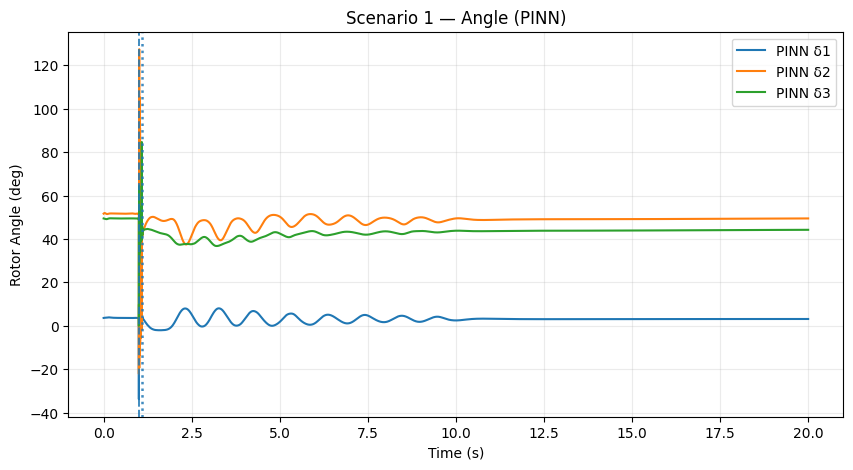

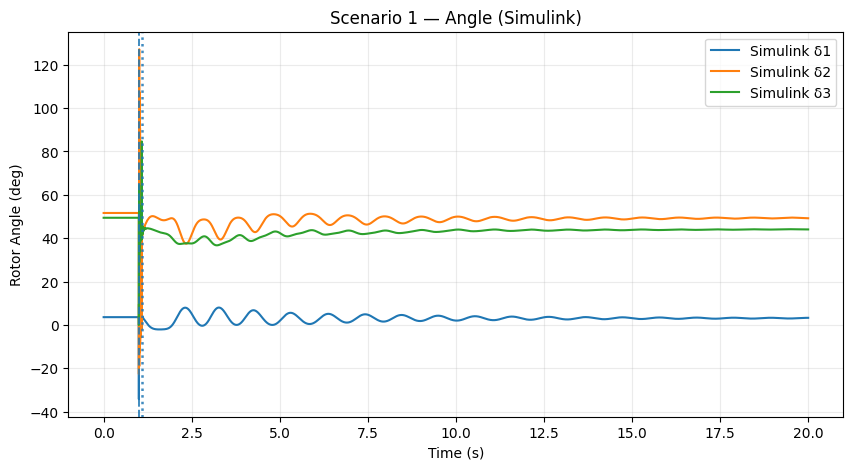

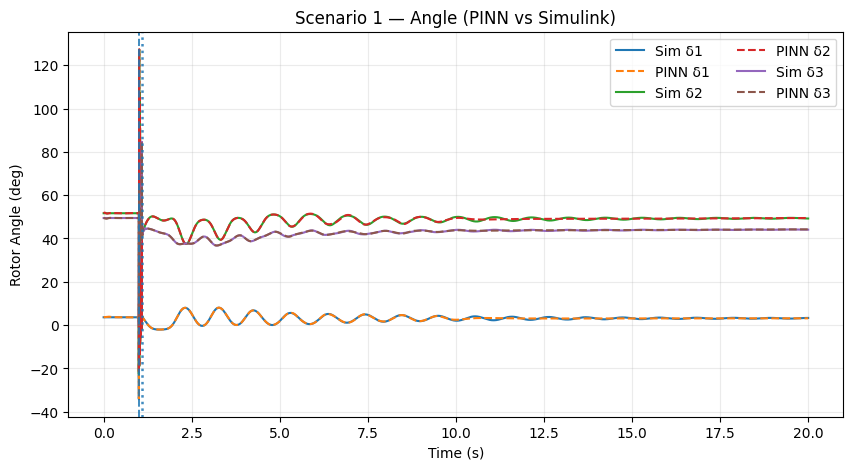

In [13]:

# -------------------------
# 1. ANGLE — PINN
# -------------------------
fig = plt.figure(figsize=(10, 5))
ax = plt.gca()

for i in range(3):
    ax.plot(T_ref, delta_pinn_plot[:, i], label=f"PINN δ{i+1}")

add_fault_markers(ax)
ax.set_title(f"Scenario {SCENARIO_ID} — Angle (PINN)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Rotor Angle (deg)")
ax.legend()
plt.show()


# -------------------------
# 2. ANGLE — SIMULINK
# -------------------------
fig = plt.figure(figsize=(10, 5))
ax = plt.gca()

for i in range(3):
    ax.plot(T_ref, delta_ref_plot[:, i], label=f"Simulink δ{i+1}")

add_fault_markers(ax)
ax.set_title(f"Scenario {SCENARIO_ID} — Angle (Simulink)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Rotor Angle (deg)")
ax.legend()
plt.show()


# -------------------------
# 3. ANGLE — COMPARISON
# -------------------------
fig = plt.figure(figsize=(10, 5))
ax = plt.gca()

for i in range(3):
    ax.plot(T_ref, delta_ref_plot[:, i], label=f"Sim δ{i+1}")
    ax.plot(T_ref, delta_pinn_plot[:, i], linestyle="--", label=f"PINN δ{i+1}")

add_fault_markers(ax)
ax.set_title(f"Scenario {SCENARIO_ID} — Angle (PINN vs Simulink)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Rotor Angle (deg)")
ax.legend(ncol=2)
plt.show()

# Speed plots

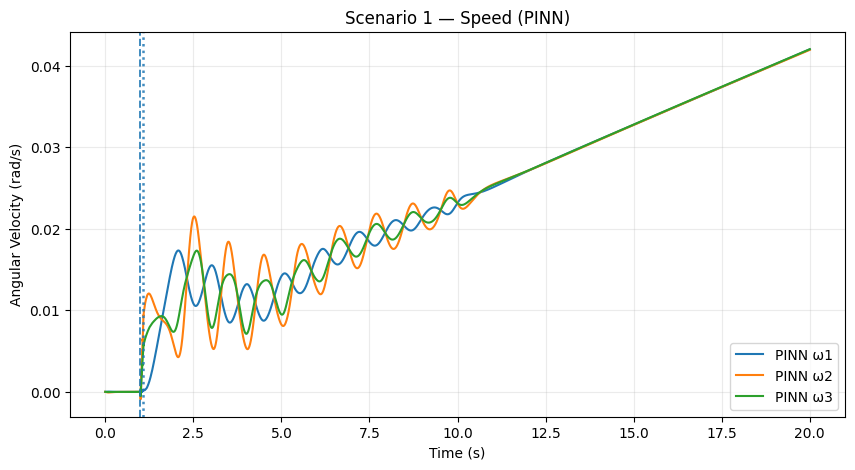

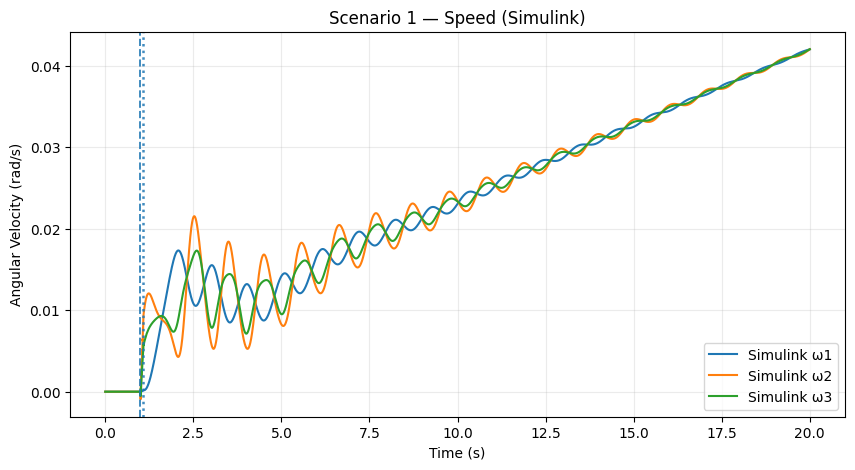

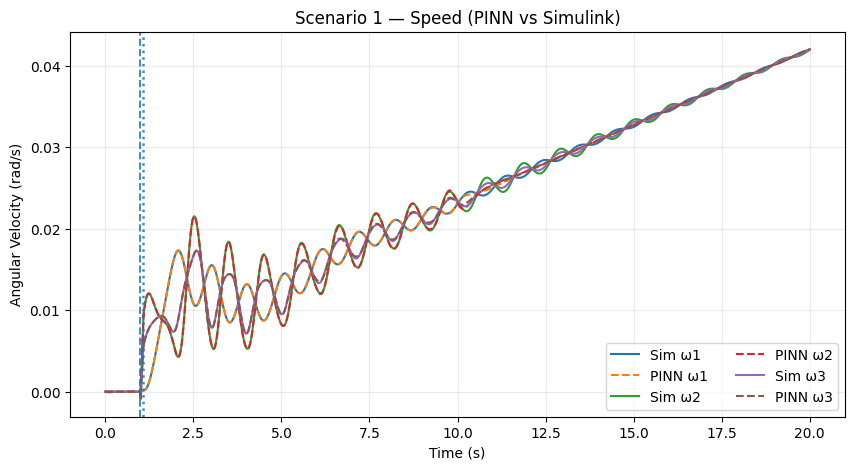

In [14]:

# -------------------------
# 4. SPEED — PINN
# -------------------------
fig = plt.figure(figsize=(10, 5))
ax = plt.gca()

for i in range(3):
    ax.plot(T_ref, omega_pinn[:, i], label=f"PINN ω{i+1}")

add_fault_markers(ax)
ax.set_title(f"Scenario {SCENARIO_ID} — Speed (PINN)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular Velocity (rad/s)")
ax.legend()
plt.show()


# -------------------------
# 5. SPEED — SIMULINK
# -------------------------
fig = plt.figure(figsize=(10, 5))
ax = plt.gca()

for i in range(3):
    ax.plot(T_ref, omega_ref[:, i], label=f"Simulink ω{i+1}")

add_fault_markers(ax)
ax.set_title(f"Scenario {SCENARIO_ID} — Speed (Simulink)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular Velocity (rad/s)")
ax.legend()
plt.show()


# -------------------------
# 6. SPEED — COMPARISON
# -------------------------
fig = plt.figure(figsize=(10, 5))
ax = plt.gca()

for i in range(3):
    ax.plot(T_ref, omega_ref[:, i], label=f"Sim ω{i+1}")
    ax.plot(T_ref, omega_pinn[:, i], linestyle="--", label=f"PINN ω{i+1}")

add_fault_markers(ax)
ax.set_title(f"Scenario {SCENARIO_ID} — Speed (PINN vs Simulink)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular Velocity (rad/s)")
ax.legend(ncol=2)
plt.show()